# Proyecto ML Churn - Telco

Objetivo: analizar el dataset de churn de clientes Telco, limpiar los datos, entrenar un modelo base y guardar un pipeline reutilizable.


## 1. Importar librerias y configuracion


In [1]:
import warnings

import joblib
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 2. Cargar datos


In [2]:
DATA_PATH = "Telco_customer_churn.csv"

df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()


Filas: 7043 | Columnas: 33


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 3. Revision y limpieza

Se corrigen los errores comunes de nombres de columnas:

- El CSV usa `Total Charges`, no `TotalCharges`.
- El CSV usa `Churn Label` y `Churn Value`, no `Churn`.

Para evitar que el resto del codigo falle, se crean alias limpios: `TotalCharges` y `Churn`.


In [3]:
# Revisar nombres reales de columnas
print(df.columns.tolist())


['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [4]:
# Eliminar espacios accidentales al inicio/final de los nombres
df.columns = df.columns.str.strip()

# Crear alias compatibles con el codigo usado en el notebook
df["TotalCharges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Churn"] = df["Churn Label"]
df["ChurnTarget"] = df["Churn Value"]

print("Nulos antes de limpieza:")
display(df[["Total Charges", "TotalCharges", "Churn", "ChurnTarget"]].isna().sum())

# Total Charges tiene valores en blanco para clientes con tenure 0; se eliminan para entrenar sin errores
filas_antes = len(df)
df = df.dropna(subset=["TotalCharges", "ChurnTarget"]).copy()
filas_eliminadas = filas_antes - len(df)

print(f"Filas eliminadas por valores faltantes criticos: {filas_eliminadas}")
print(f"Filas finales: {len(df)}")


Nulos antes de limpieza:


Total Charges     0
TotalCharges     11
Churn             0
ChurnTarget       0
dtype: int64

Filas eliminadas por valores faltantes criticos: 11
Filas finales: 7032


In [5]:
# Revision rapida de duplicados y tipos
print("Duplicados:", df.duplicated().sum())
display(df.info())


Duplicados: 0
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7032 non-null   str    
 1   Count              7032 non-null   int64  
 2   Country            7032 non-null   str    
 3   State              7032 non-null   str    
 4   City               7032 non-null   str    
 5   Zip Code           7032 non-null   int64  
 6   Lat Long           7032 non-null   str    
 7   Latitude           7032 non-null   float64
 8   Longitude          7032 non-null   float64
 9   Gender             7032 non-null   str    
 10  Senior Citizen     7032 non-null   str    
 11  Partner            7032 non-null   str    
 12  Dependents         7032 non-null   str    
 13  Tenure Months      7032 non-null   int64  
 14  Phone Service      7032 non-null   str    
 15  Multiple Lines     7032 non-null   str    
 16  Internet Service   7032 no

None

## 4. Analisis exploratorio


In [6]:
# Distribucion de la variable objetivo
distribucion = df["Churn"].value_counts()
distribucion


Churn
No     5163
Yes    1869
Name: count, dtype: int64

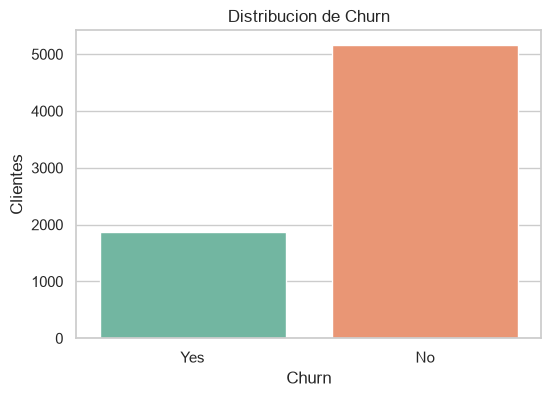

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("Distribucion de Churn")
plt.xlabel("Churn")
plt.ylabel("Clientes")
plt.show()


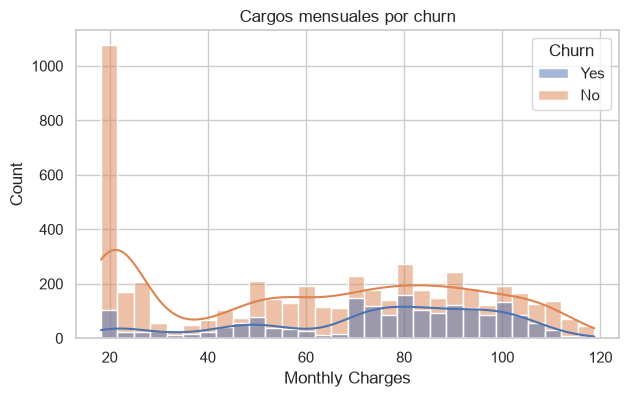

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Monthly Charges", hue="Churn", kde=True, bins=30)
plt.title("Cargos mensuales por churn")
plt.xlabel("Monthly Charges")
plt.show()


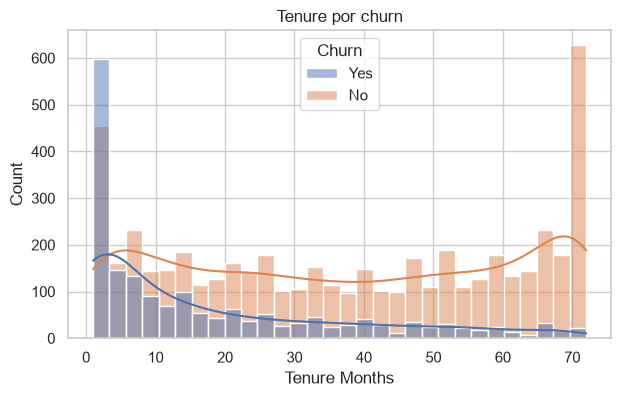

In [9]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Tenure Months", hue="Churn", kde=True, bins=30)
plt.title("Tenure por churn")
plt.xlabel("Tenure Months")
plt.show()


## 5. Preparar datos para modelado

Se excluyen identificadores, columnas de fuga de informacion y columnas duplicadas creadas solo para compatibilidad.


In [10]:
target = "ChurnTarget"

leakage_or_unused = [
    "CustomerID",
    "Churn Label",
    "Churn Value",
    "Churn",
    "ChurnTarget",
    "Churn Score",
    "CLTV",
    "Churn Reason",
    "Total Charges",
    "Lat Long",
]

X = df.drop(columns=[col for col in leakage_or_unused if col in df.columns])
y = df[target]

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Variables numericas:", numeric_features)
print("Variables categoricas:", categorical_features)
print("Forma de X:", X.shape)


Variables numericas: ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'TotalCharges']
Variables categoricas: ['Country', 'State', 'City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Forma de X: (7032, 26)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (5625, 26) Test: (1407, 26)


## 6. Entrenar pipeline base


In [12]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

modelo = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", modelo),
    ]
)

pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['Count','Country','State',...,'Payment Method','Monthly Charges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrou

## 7. Evaluacion


In [13]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred))


Accuracy: 0.7925
ROC AUC: 0.8329

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.72      1407
weighted avg       0.79      0.79      0.79      1407



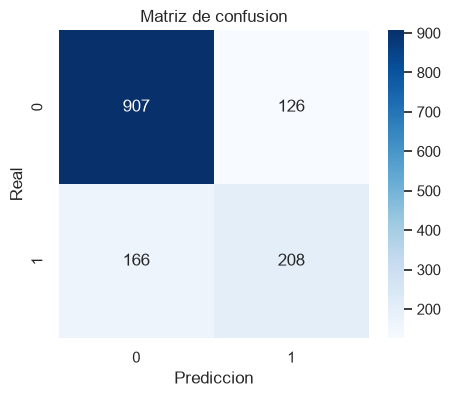

In [14]:
matriz = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusion")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.show()


## 8. Guardar pipeline


In [15]:
MODEL_PATH = "pipeline_churn_telco.pkl"
joblib.dump(pipeline, MODEL_PATH)
print(f"Pipeline guardado en: {MODEL_PATH}")


Pipeline guardado en: pipeline_churn_telco.pkl


## 9. Resumen

Correcciones aplicadas:

- `df["TotalCharges"]` ahora se crea desde `df["Total Charges"]`.
- `df["Churn"]` ahora se crea desde `df["Churn Label"]`.
- La variable objetivo para modelado es `df["ChurnTarget"]`, creada desde `df["Churn Value"]`.
- Se eliminan los valores vacios de `Total Charges` antes de entrenar.
- Se guarda el pipeline entrenado en `pipeline_churn_telco.pkl`.
